In [1]:
import numpy as np
import scipy.stats as sps
import scipy.optimize as spo

from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Logistic regression loss function

In [2]:
def fun_logistic(param, x):
    '''
    Returns 1./(1+exp(-(b0 + b1 * x))), array
    '''
    p = np.polynomial.Polynomial(param) # b0 + b1*x etc
    out = 1+np.exp(-1.*p(x))
    return 1./out

In [3]:
def fun_loss(param,
             x=None,
             y=None):
    p = fun_logistic(param, x)

    aa = y*np.log(p)+(1-y)*np.log(1.-p)
    
    return -1.*np.sum(aa)

## Trying out wiki example (1D data)
https://en.wikipedia.org/wiki/Logistic_regression

In [4]:
hours = np.array([0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
        2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50])
outcome = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

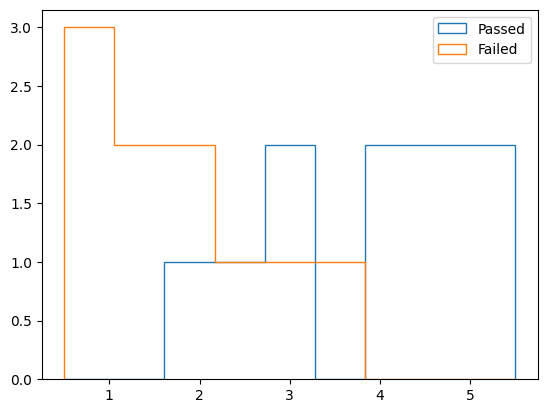

In [5]:
nbins = 10
bin_edges = np.linspace(min(hours), max(hours), nbins)
mask = outcome==1
plt.hist(hours[mask], bins = bin_edges, histtype='step', label='Passed')

mask = outcome==0
plt.hist(hours[mask], bins = bin_edges, histtype='step', label='Failed')
plt.legend()

In [6]:
x0 = np.array([1, 1])

res = spo.minimize(fun_loss,
                   x0,
                   args=(hours, outcome),
                   method=None
                  )

In [7]:
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 8.029878464344716
        x: [-4.078e+00  1.505e+00]
      nit: 9
      jac: [ 0.000e+00  4.768e-07]
 hess_inv: [[ 2.970e+00 -9.860e-01]
            [-9.860e-01  3.773e-01]]
     nfev: 30
     njev: 10

In [8]:
bf = res.x

In [9]:
X = hours.reshape(-1, 1) # Cause sklearn wants it as a 2d array

lr_model = LogisticRegression(penalty=None, # no regularization
                              solver='lbfgs')
lr_model.fit(X, outcome)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
# Get coefficients
print(f"Intercept: {lr_model.intercept_[0]:.4f}")
print(f"Coefficient: {lr_model.coef_[0][0]:.4f}")

Intercept: -4.0787
Coefficient: 1.5050


Text(0, 0.5, 'Probability of passing exam')

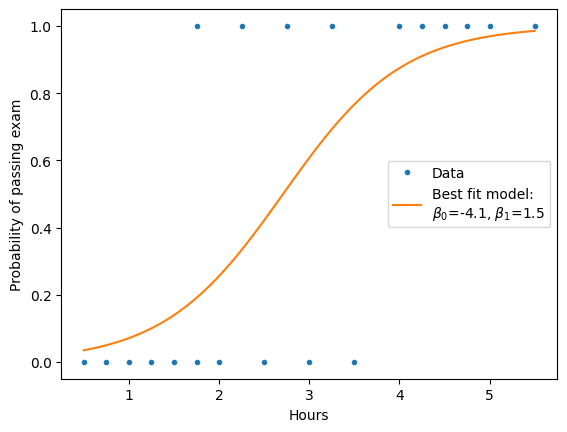

In [11]:
xx = np.linspace(hours.min(), hours.max(), 100)
yy = fun_logistic(bf, xx)

plt.plot(hours, outcome, '.', label='Data')
plt.plot(xx, yy,
         label=f'Best fit model:\n$\\beta_0$={bf[0]:.1f}, $\\beta_1$={bf[1]:.1f}')
plt.legend(loc='center right')
plt.xlabel('Hours')
plt.ylabel('Probability of passing exam')

## My own example (1D data)
Just 2 Gaussians somewhat separated closely

In [12]:
mu_bag = [0, 2.]
std_bag = [1., 1.]
n_bag = [10, 10]

hours = []
outcome = []
for _ind, (_mu, _std) in enumerate(zip(mu_bag, std_bag)):
    _n = n_bag[_ind]
    hours.append(sps.norm.rvs(loc=_mu, scale=_std, size=_n))
    outcome.append(_ind*np.ones(_n))
    
hours = np.array(hours).flatten()
outcome = np.array(outcome).flatten()

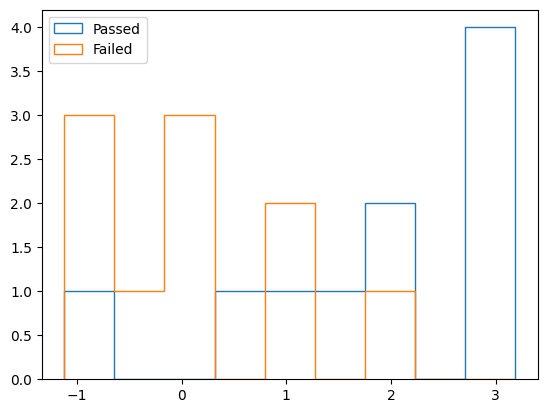

In [13]:
nbins = 10
bin_edges = np.linspace(min(hours), max(hours), nbins)
mask = outcome==1
plt.hist(hours[mask], bins = bin_edges, histtype='step', label='Passed')

mask = outcome==0
plt.hist(hours[mask], bins = bin_edges, histtype='step', label='Failed')
plt.legend()

In [14]:
x0 = np.array([1, 1])

res = spo.minimize(fun_loss,
                   x0,
                   args=(hours, outcome),
                   method=None
                  )

In [15]:
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 9.821493309283692
        x: [-1.058e+00  1.124e+00]
      nit: 9
      jac: [ 5.960e-07  5.960e-07]
 hess_inv: [[ 4.977e-01 -2.224e-01]
            [-2.224e-01  2.374e-01]]
     nfev: 33
     njev: 11

In [16]:
bf = res.x

In [17]:
X = hours.reshape(-1, 1) # Cause sklearn wants it as a 2d array

lr_model = LogisticRegression(penalty=None, # no regularization
                              solver='lbfgs')
lr_model.fit(X, outcome)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
# Get coefficients
print(f"Intercept: {lr_model.intercept_[0]:.4f}")
print(f"Coefficient: {lr_model.coef_[0][0]:.4f}")

Intercept: -1.0582
Coefficient: 1.1237


Text(0, 0.5, 'Probability of passing exam')

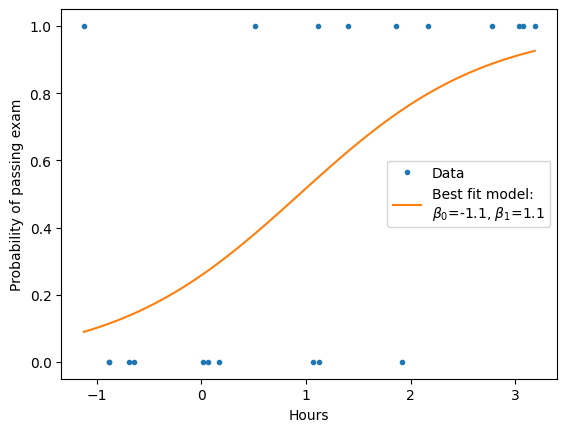

In [19]:
xx = np.linspace(hours.min(), hours.max(), 100)
yy = fun_logistic(bf, xx)

plt.plot(hours, outcome, '.', label='Data')
plt.plot(xx, yy,
         label=f'Best fit model:\n$\\beta_0$={bf[0]:.1f}, $\\beta_1$={bf[1]:.1f}')
plt.legend(loc='center right')
plt.xlabel('Hours')
plt.ylabel('Probability of passing exam')

## Multiple linear logistic regression 
More than 1 regressor (independent variables), but still 1 target (classifier, dependent variable). Binary outcome.

Still just 2 2D-Gaussians somewhat separated closely.

In [20]:
mu_bag2 = ([0, 0], [2, 1])
cov_bag2 = ([[1, 0.8], [0.8, 1]],
           [[2, 0.5], [0.5, 1]])
n_bag2 = [100, 100]

hours = []
outcome = []
for _ind, (_mu, _cov) in enumerate(zip(mu_bag2, cov_bag2)):
    _n = n_bag2[_ind]
    _samples = sps.multivariate_normal(_mu, _cov).rvs(size=_n)
    hours.append(_samples)
    outcome.append(_ind*np.ones(_n))

hours = np.vstack(hours)
outcome = np.array(outcome).flatten()

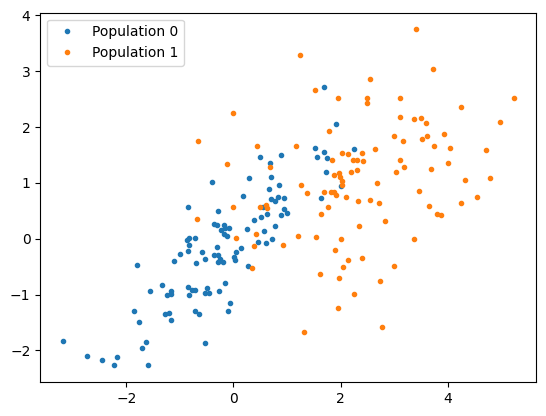

In [21]:
for _ind in range(2):
    mask = outcome==_ind
    plt.plot(hours[mask, 0], hours[mask,1], '.', label=f'Population {_ind}')
plt.legend()

In [22]:
def fun_logistic_2d(param, x):
    '''
    Returns 1./(1+exp(-(b0 + b1 * x))), array
    '''
    p = param[0] + param[1]*x[:,0] + param[2]*x[:,1]
    out = 1+np.exp(-1.*p)
    return 1./out

In [23]:
def fun_loss_2d(param,
             x=None,
             y=None):
    p = fun_logistic_2d(param, x)

    aa = y*np.log(p)+(1-y)*np.log(1.-p)
    
    return -1.*np.sum(aa)

In [24]:
x0 = np.array([1, 1, 1])

res2 = spo.minimize(fun_loss_2d,
                   x0,
                   args=(hours, outcome),
                   method=None
                  )

In [25]:
res2

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 66.00390053080872
        x: [-1.776e+00  1.742e+00 -4.542e-04]
      nit: 12
      jac: [ 0.000e+00  0.000e+00  0.000e+00]
 hess_inv: [[ 1.027e-01 -4.918e-02 -9.956e-03]
            [-4.918e-02  6.732e-02 -2.927e-02]
            [-9.956e-03 -2.927e-02  6.609e-02]]
     nfev: 60
     njev: 15

In [26]:
bf2 = res2.x

In [27]:
lr_model = LogisticRegression(penalty=None, # no regularization
                              solver='lbfgs')
lr_model.fit(hours, outcome)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
# Get coefficients
print(f'sklearn bf: {lr_model.intercept_[0]:.4f}, {lr_model.coef_[0][0]:.4f}, {lr_model.coef_[0][1]:.4f}')

sklearn bf: -1.7766, 1.7419, -0.0000


In [29]:
bf2

array([-1.77617548e+00,  1.74210392e+00, -4.54212234e-04])

In [30]:
nx = 10
ny = 10
xx = np.linspace(hours[:, 0].min(), hours[:, 0].max(), nx)
yy = np.linspace(hours[:, 1].min(), hours[:, 1].max(), ny)
XX, YY = np.meshgrid(xx, yy)

In [31]:
bf_model = np.zeros((nx, ny))
for ii in range(nx):
    pt = np.array((XX[ii, :], YY[ii, :])).T
    bf_model[ii, :] = fun_logistic_2d(bf2, pt)

Text(0, 0.5, 'Dimension 1')

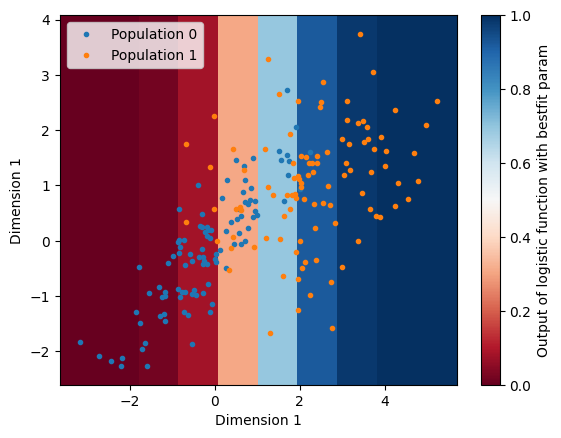

In [32]:
# Create diverging norm centered at 0.5
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

cb = plt.pcolor(XX, YY, bf_model, cmap='RdBu', norm=norm)
for _ind in range(2):
    mask = outcome==_ind
    plt.plot(hours[mask, 0], hours[mask,1], '.', label=f'Population {_ind}')
plt.colorbar(cb, label='Output of logistic function with bestfit param')
plt.legend()
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 1')

Just use sklearn, lol.